## Evaluating 6-31G** from cc-pvdz training checkpoints

In [1]:
import shutil
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyblock.blocking

from jaqmc.utils.config import ConfigManager

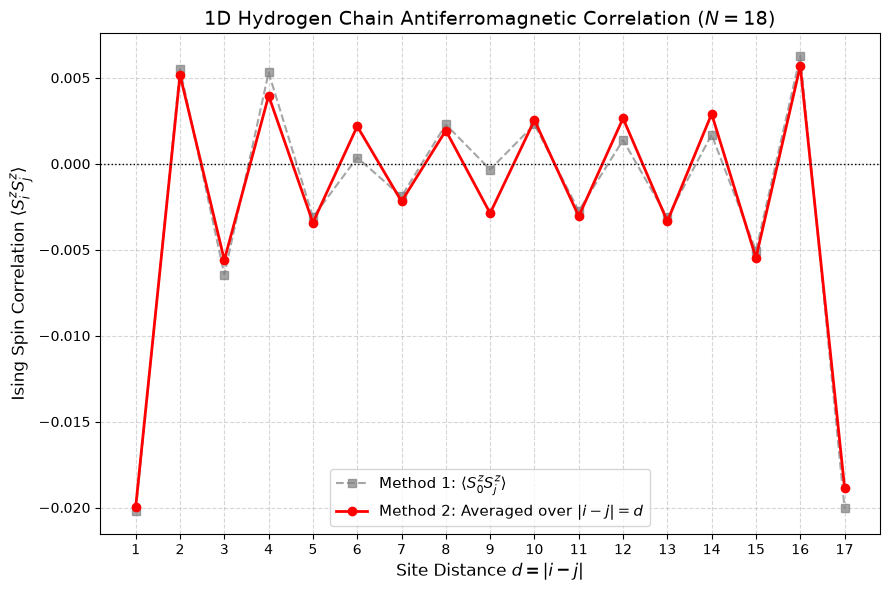

=== Detailed Pairs for each |i-j| ===

Distance d = 1:
  <S_0^z S_1^z> : -0.020204
  <S_1^z S_0^z> : -0.021005
  <S_1^z S_2^z> : -0.020485
  <S_2^z S_1^z> : -0.020635
  <S_2^z S_3^z> : -0.020746
  <S_3^z S_2^z> : -0.019313
  <S_3^z S_4^z> : -0.019001
  <S_4^z S_3^z> : -0.018975
  <S_4^z S_5^z> : -0.020180
  <S_5^z S_4^z> : -0.022065
  <S_5^z S_6^z> : -0.020998
  <S_6^z S_5^z> : -0.022147
  <S_6^z S_7^z> : -0.021243
  <S_7^z S_6^z> : -0.021498
  <S_7^z S_8^z> : -0.017413
  <S_8^z S_7^z> : -0.018922
  <S_8^z S_9^z> : -0.019839
  <S_9^z S_8^z> : -0.019544
  <S_9^z S_10^z> : -0.019732
  <S_10^z S_9^z> : -0.019215
  <S_10^z S_11^z> : -0.017407
  <S_11^z S_10^z> : -0.016010
  <S_11^z S_12^z> : -0.018898
  <S_12^z S_11^z> : -0.019887
  <S_12^z S_13^z> : -0.019257
  <S_13^z S_12^z> : -0.020046
  <S_13^z S_14^z> : -0.021043
  <S_14^z S_13^z> : -0.019499
  <S_14^z S_15^z> : -0.019933
  <S_15^z S_14^z> : -0.019774
  <S_15^z S_16^z> : -0.020774
  <S_16^z S_15^z> : -0.021018
  <S_16^z S_17^z> : -0.

In [4]:
#Eval 6233 steps
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest /rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_18_rdm_eval_all_gaussian_init
path = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_2.8_18_631g_eval" 
digest_file = os.path.join(path, "evaluation_digest_6233.npz")
digest = dict(np.load(digest_file))

# Extract the 18-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 18

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 17

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=18$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 4. Printing Detailed Pair Outputs & Summary
# =====================================================================
print("=== Detailed Pairs for each |i-j| ===")
for d in distances:
    print(f"\nDistance d = {d}:")
    for (i, j), val in detailed_pairs[d]:
        print(f"  <S_{i}^z S_{j}^z> : {val:+.6f}")

print("\n\n=== Summary Table ===")
print("Distance | Method 1      | Method 2 (Averaged)")
print("-" * 50)
for d, v1, v2 in zip(distances, correlations_m1, correlations_m2):
    print(f"   {d}     |  {v1:+.6f}  |  {v2:+.6f}")

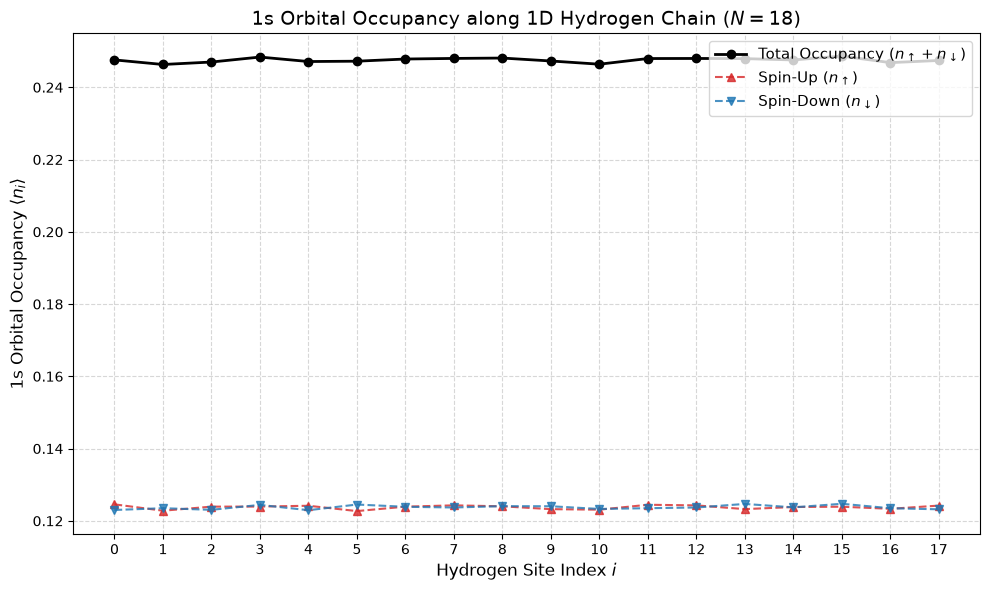

=== 1s Orbital Occupancies ===
Site |   Up   |  Down  |  Total 
-----------------------------------
  0  | 0.1246 | 0.1230 | 0.2476
  1  | 0.1228 | 0.1235 | 0.2463
  2  | 0.1239 | 0.1231 | 0.2470
  3  | 0.1240 | 0.1244 | 0.2484
  4  | 0.1242 | 0.1230 | 0.2471
  5  | 0.1227 | 0.1245 | 0.2472
  6  | 0.1239 | 0.1239 | 0.2478
  7  | 0.1243 | 0.1237 | 0.2480
  8  | 0.1240 | 0.1241 | 0.2481
  9  | 0.1232 | 0.1240 | 0.2473
 10  | 0.1231 | 0.1233 | 0.2464
 11  | 0.1245 | 0.1235 | 0.2480
 12  | 0.1243 | 0.1237 | 0.2480
 13  | 0.1233 | 0.1247 | 0.2479
 14  | 0.1238 | 0.1237 | 0.2476
 15  | 0.1239 | 0.1247 | 0.2486
 16  | 0.1233 | 0.1235 | 0.2468
 17  | 0.1242 | 0.1232 | 0.2474


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest
path = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_2.8_18_631g_eval_ccpvdz_train" 
digest_file = os.path.join(path, "evaluation_digest_6233.npz")
digest = dict(np.load(digest_file))

# Extract the 1RDM arrays
# Standard JaQMC output keys for the 1-particle RDM
g1_u = digest['gamma1_up_ii']
g1_d = digest['gamma1_down_ii']

n_sites = 18

# =====================================================================
# 1. Calculate Occupancies
# =====================================================================
# The occupancy of the i-th orbital is the diagonal element [i, i] of the 1RDM
# Extract the diagonals and take the real part (imaginary part is QMC noise)
if g1_u.ndim == 1:
    occ_up = g1_u.real
    occ_down = g1_d.real
else:
    occ_up = np.diag(g1_u).real
    occ_down = np.diag(g1_d).real

# Total 1s occupancy per site is the sum of up and down spins
occ_total = occ_up + occ_down

# =====================================================================
# 2. Plotting
# =====================================================================
sites = np.arange(n_sites)

plt.figure(figsize=(10, 6))

# Plot total occupancy
plt.plot(sites, occ_total, marker='o', linestyle='-', color='black', linewidth=2, 
         label=r'Total Occupancy ($n_{\uparrow} + n_{\downarrow}$)')

# Plot individual spin channels to check for spin polarization symmetry
plt.plot(sites, occ_up, marker='^', linestyle='--', color='tab:red', alpha=0.8, 
         label=r'Spin-Up ($n_{\uparrow}$)')
plt.plot(sites, occ_down, marker='v', linestyle='--', color='tab:blue', alpha=0.8, 
         label=r'Spin-Down ($n_{\downarrow}$)')

# Draw a horizontal line at 1.0 (ideal half-filling reference)
# plt.axhline(1.0, color='gray', linewidth=1, linestyle=':', label='Ideal Half-Filling (1.0)')

plt.xlabel(r"Hydrogen Site Index $i$", fontsize=12)
plt.ylabel(r"1s Orbital Occupancy $\langle n_i \rangle$", fontsize=12)
plt.title(r"1s Orbital Occupancy along 1D Hydrogen Chain ($N=18$)", fontsize=14)
plt.xticks(sites)
# plt.ylim(0, 1.5) # Adjusted for expected occupancies around 1.0
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# =====================================================================
# 3. Printing Summary Table
# =====================================================================
print("=== 1s Orbital Occupancies ===")
print("Site |   Up   |  Down  |  Total ")
print("-" * 35)
for i in range(n_sites):
    print(f" {i:2d}  | {occ_up[i]:.4f} | {occ_down[i]:.4f} | {occ_total[i]:.4f}")

In [6]:
g1_u

array([0.12456948-3.3880735e-06j, 0.12281003-5.5929416e-07j,
       0.12393647-3.0857277e-06j, 0.12395375+2.2388194e-06j,
       0.12417919+4.5052125e-06j, 0.12270728+2.2152490e-06j,
       0.12393206-1.3320287e-05j, 0.12429236+1.9151830e-06j,
       0.12402359+6.9643136e-07j, 0.1232402 +2.1617564e-06j,
       0.1230981 +7.9317743e-07j, 0.12445639-4.7477042e-06j,
       0.12428246+5.2439060e-07j, 0.12325157-1.0739677e-06j,
       0.12383254-5.6844499e-07j, 0.12391491-1.7573769e-06j,
       0.12333363+4.7570184e-06j, 0.12422491+6.7923056e-06j],
      dtype=complex64)

## 6-31G** evaluation with 6-31G** training checkpoints

In [2]:
# 8000 evaluation steps
import numpy as np
import matplotlib.pyplot as plt
import os

# Load your digest /rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_18_rdm_eval_all_gaussian_init
path = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_2.8_18_631g_eval" 
digest_file = os.path.join(path, "evaluation_digest.npz")
digest = dict(np.load(digest_file))

# Extract the 18-orbital 2RDM arrays
g2_uu = digest['two_rdm_up_up']
g2_dd = digest['two_rdm_down_down']
g2_ud = digest['two_rdm_up_down']

n_sites = 18

# =====================================================================
# 1. Build the <S_i^z S_j^z> Matrix
# =====================================================================
# Extract the ijij and jiji elements for the Ising term
nn_uu = np.einsum('ijij->ij', g2_uu)
nn_dd = np.einsum('ijij->ij', g2_dd)
nn_ud = np.einsum('ijij->ij', g2_ud)
nn_du = np.einsum('jiji->ij', g2_ud) 

# Apply your exact formula
sz_sz_matrix = (nn_uu + nn_dd - nn_ud - nn_du) # * 0.25 (remove to follow paper's scaling)

# Take the real part (imaginary part is just QMC noise)
sz_sz_matrix = sz_sz_matrix.real

# =====================================================================
# 2. Extract Correlations by Distance |i-j| (Skipping d=0)
# =====================================================================
# We start the range at 1 to skip the d=0 on-site value completely
distances = np.arange(1, n_sites) # 1 to 17

# Method 1: Anchored to i=0
correlations_m1 = [sz_sz_matrix[0, d] for d in distances]

# Method 2: Averaged over all translationally equivalent pairs (and storing pairs)
correlations_m2 = []
detailed_pairs = {}

for d in distances:
    pairs_for_d = []
    for i in range(n_sites):
        for j in range(n_sites):
            if abs(i - j) == d:
                pairs_for_d.append(((i, j), sz_sz_matrix[i, j]))
                
    # Calculate the average for Method 2
    avg_val = np.mean([val for _, val in pairs_for_d])
    correlations_m2.append(avg_val)
    detailed_pairs[d] = pairs_for_d

# =====================================================================
# 3. Plotting
# =====================================================================
plt.figure(figsize=(9, 6))

# Plot Method 1
plt.plot(distances, correlations_m1, marker='s', linestyle='--', color='gray', alpha=0.7, 
         label=r'Method 1: $\langle S_0^z S_j^z \rangle$')

# Plot Method 2
plt.plot(distances, correlations_m2, marker='o', linestyle='-', color='r', linewidth=2, 
         label=r'Method 2: Averaged over $|i-j|=d$')

# Draw a horizontal line at 0 for visual reference
plt.axhline(0, color='black', linewidth=1, linestyle=':')

plt.xlabel(r"Site Distance $d = |i - j|$", fontsize=12)
plt.ylabel(r"Ising Spin Correlation $\langle S_i^z S_j^z \rangle$", fontsize=12)
plt.title(r"1D Hydrogen Chain Antiferromagnetic Correlation ($N=18$)", fontsize=14)
plt.xticks(distances)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

KeyError: 'two_rdm_up_up'

## Other occupancies